
1) Monthly Revenue Trend: Shows how total revenue changes month by month. This helps identify growth patterns or seasonal effects.


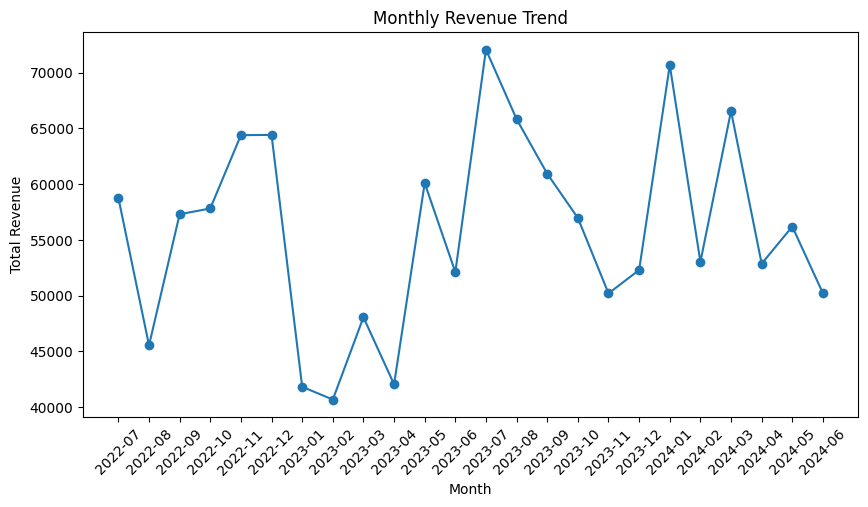


2) Monthly Transaction Volume: Displays the number of transactions each month. Useful for spotting activity spikes or declines.


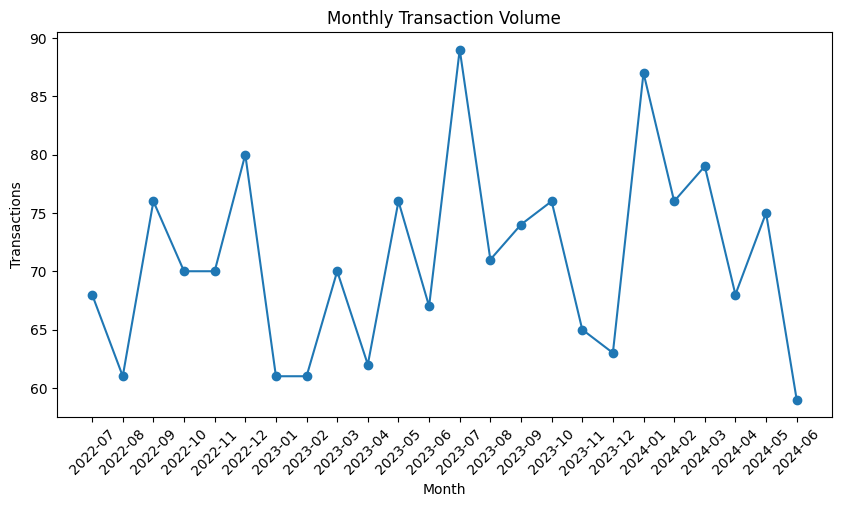


3) New vs Repeat Customers per Month: Differentiates between new customers and those returning. This reveals customer retention dynamics.


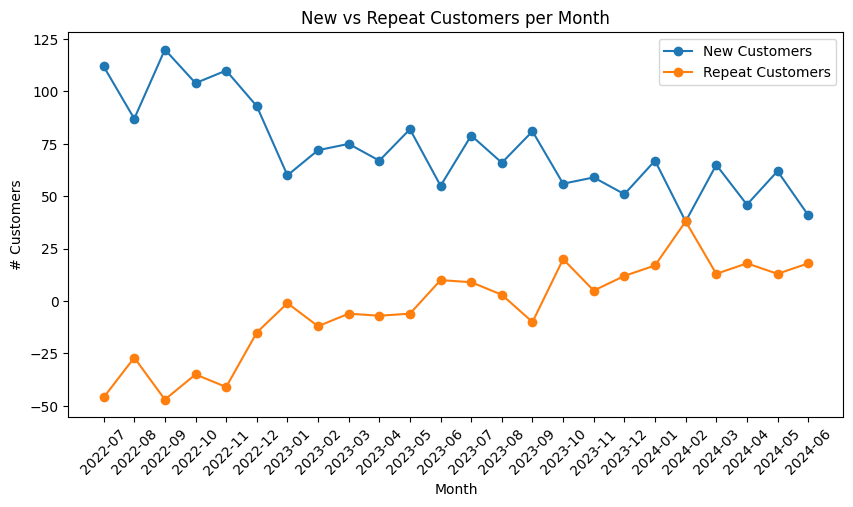


4) Payment Method Share Over Time: Shows the share of different payment methods monthly. Useful for tracking shifts in customer preferences.


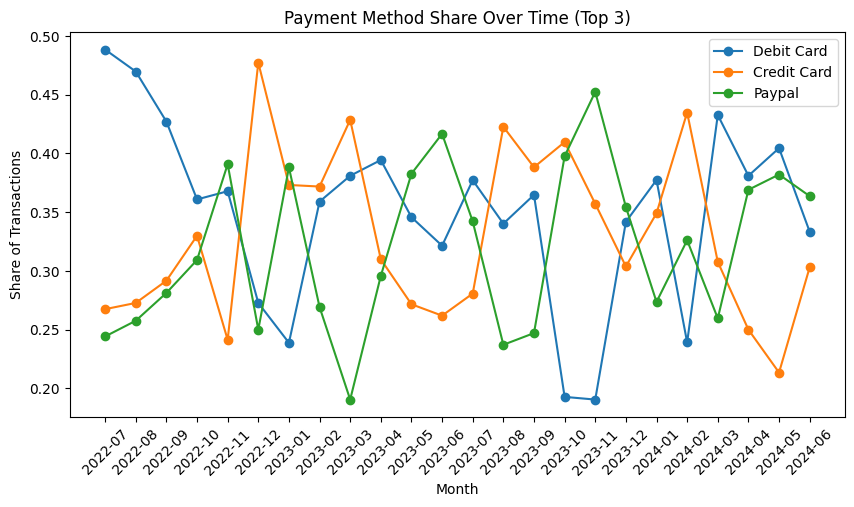


5) Product Category: Revenue & High-Spender Rate: Bar shows total revenue per category, line shows % of high-spenders. Helps identify profitable segments.


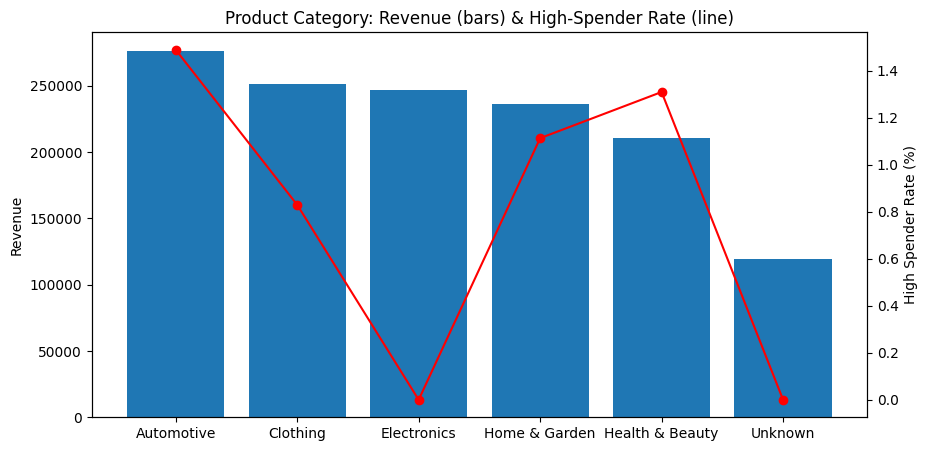


6) Average Transaction Amount by Age Band: Compares spending across age groups. Useful for segmenting marketing strategies.


C:\Users\chang\AppData\Local\Temp\ipykernel_9268\3705089326.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_age = df.dropna(subset=["AgeBand","Amount"]).groupby("AgeBand")["Amount"].mean()


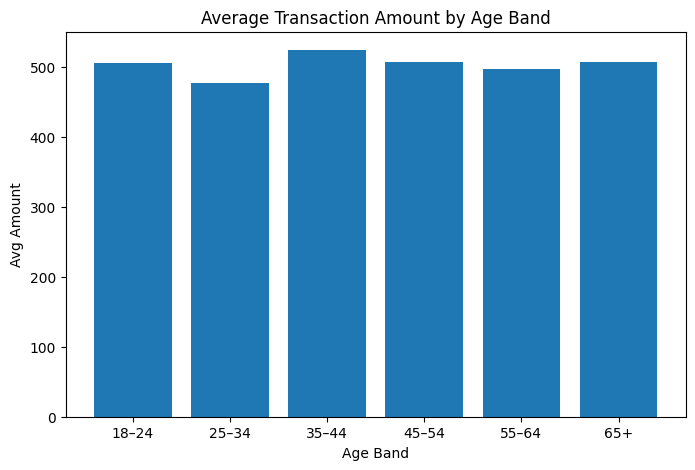


7) Positive Sentiment Share Over Time: Tracks customer sentiment trends on social platforms. Useful for brand health monitoring.


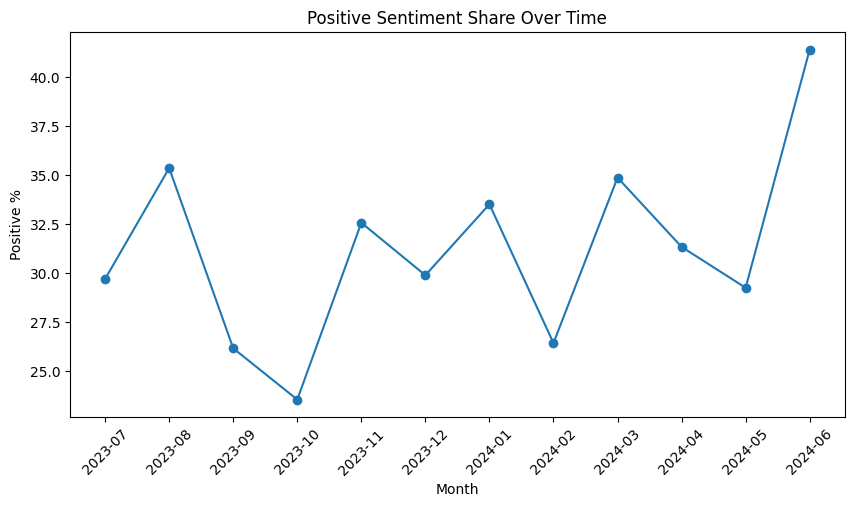


8) Platform Interaction Volume Over Time: Tracks customer engagement volume by platform. Helps identify the most effective digital channels.


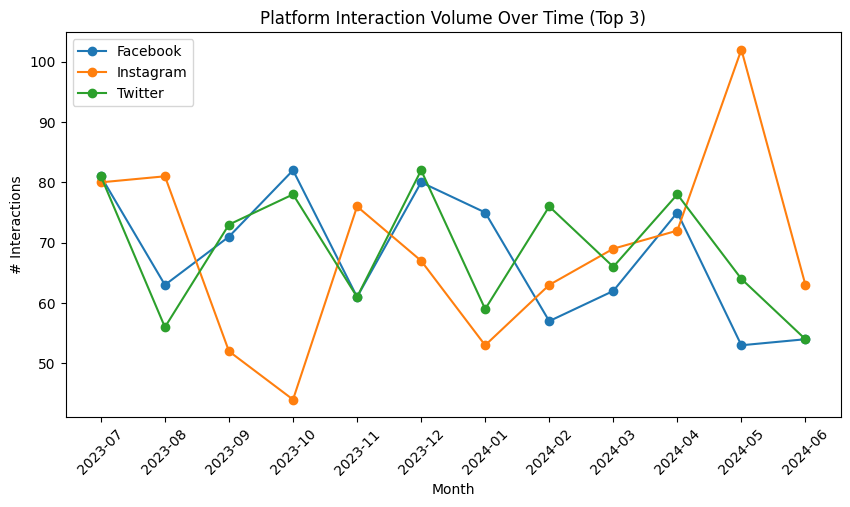

In [3]:
# ===================================
# 1. Import Libraries
# ===================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===================================
# 2. Load Dataset
# ===================================
file_path = r"C:\Users\chang\Desktop\ML\MO-IT162-Math-for-Machine-Learning-TEAM2\src\data\final_merged_dataset.csv"
df = pd.read_csv(file_path)

# Convert date columns
date_cols = ["TransactionDate", "InteractionDate", "SignupDate"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Ensure numeric
if "Amount" in df.columns:
    df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

if "IsHighSpender" in df.columns:
    df["IsHighSpender"] = pd.to_numeric(df["IsHighSpender"], errors="coerce").fillna(0).astype(int)

# Create age bands
if "Age" in df.columns:
    bins = [18, 25, 35, 45, 55, 65, 100]
    labels = ["18–24", "25–34", "35–44", "45–54", "55–64", "65+"]
    df["AgeBand"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True)

# Helper functions
def to_month(series):
    return series.dt.to_period("M").astype(str)

def top_n(series, n=5):
    return list(series.value_counts().head(n).index)


# ===================================
# 3. VISUALIZATIONS WITH EXPLANATIONS
# ===================================

# --- 1) Monthly Revenue Trend
print("\n1) Monthly Revenue Trend: Shows how total revenue changes month by month. This helps identify growth patterns or seasonal effects.")
temp = df.dropna(subset=["TransactionDate", "Amount"]).copy()
temp["Month"] = to_month(temp["TransactionDate"])
ts = temp.groupby("Month")["Amount"].sum().sort_index()

plt.figure(figsize=(10,5))
plt.plot(ts.index, ts.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month"); plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


# --- 2) Monthly Transaction Volume
print("\n2) Monthly Transaction Volume: Displays the number of transactions each month. Useful for spotting activity spikes or declines.")
temp = df.dropna(subset=["TransactionDate"]).copy()
temp["Month"] = to_month(temp["TransactionDate"])
tv = temp.groupby("Month")["TransactionID"].nunique()
plt.figure(figsize=(10,5))
plt.plot(tv.index, tv.values, marker="o")
plt.title("Monthly Transaction Volume")
plt.xlabel("Month"); plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.show()


# --- 3) New vs Repeat Customers per Month
print("\n3) New vs Repeat Customers per Month: Differentiates between new customers and those returning. This reveals customer retention dynamics.")
temp = df.dropna(subset=["TransactionDate", "CustomerID"]).copy()
first_purchase = temp.groupby("CustomerID")["TransactionDate"].min()
temp["FirstPurchaseDate"] = temp["CustomerID"].map(first_purchase)
temp["Month"] = to_month(temp["TransactionDate"])
temp["IsNewCustomer"] = temp["TransactionDate"].dt.to_period("M") == temp["FirstPurchaseDate"].dt.to_period("M")

new_by_month = temp.groupby("Month")["IsNewCustomer"].sum()
active_by_month = temp.groupby("Month")["CustomerID"].nunique()
repeat_by_month = active_by_month - new_by_month

plt.figure(figsize=(10,5))
plt.plot(new_by_month.index, new_by_month.values, marker="o", label="New Customers")
plt.plot(repeat_by_month.index, repeat_by_month.values, marker="o", label="Repeat Customers")
plt.title("New vs Repeat Customers per Month")
plt.xlabel("Month"); plt.ylabel("# Customers")
plt.xticks(rotation=45); plt.legend()
plt.show()


# --- 4) Payment Method Share Over Time
print("\n4) Payment Method Share Over Time: Shows the share of different payment methods monthly. Useful for tracking shifts in customer preferences.")
temp = df.dropna(subset=["PaymentMethod", "TransactionDate"]).copy()
top_methods = top_n(temp["PaymentMethod"], 3)
temp["Month"] = to_month(temp["TransactionDate"])
pm = temp.groupby(["Month","PaymentMethod"]).size().unstack(fill_value=0)
pm = pm[top_methods]
pm_share = pm.div(pm.sum(axis=1), axis=0)

plt.figure(figsize=(10,5))
for col in pm_share.columns:
    plt.plot(pm_share.index, pm_share[col].values, marker="o", label=col)
plt.title("Payment Method Share Over Time (Top 3)")
plt.xlabel("Month"); plt.ylabel("Share of Transactions")
plt.xticks(rotation=45); plt.legend()
plt.show()


# --- 5) Product Category: Revenue & High-Spender Rate
print("\n5) Product Category: Revenue & High-Spender Rate: Bar shows total revenue per category, line shows % of high-spenders. Helps identify profitable segments.")
temp = df.dropna(subset=["ProductCategory", "Amount"]).copy()
top_cats = top_n(temp["ProductCategory"], 8)
temp = temp[temp["ProductCategory"].isin(top_cats)]
revenue = temp.groupby("ProductCategory")["Amount"].sum().sort_values(ascending=False)
hs_rate = temp.groupby("ProductCategory")["IsHighSpender"].mean().reindex(revenue.index)

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.bar(revenue.index, revenue.values)
ax1.set_ylabel("Revenue")
ax2 = ax1.twinx()
ax2.plot(hs_rate.index, hs_rate.values*100, marker="o", color="red")
ax2.set_ylabel("High Spender Rate (%)")
plt.title("Product Category: Revenue (bars) & High-Spender Rate (line)")
plt.xticks(rotation=45)
plt.show()


# --- 6) Average Transaction Amount by Age Band
print("\n6) Average Transaction Amount by Age Band: Compares spending across age groups. Useful for segmenting marketing strategies.")
avg_age = df.dropna(subset=["AgeBand","Amount"]).groupby("AgeBand")["Amount"].mean()
plt.figure(figsize=(8,5))
plt.bar(avg_age.index.astype(str), avg_age.values)
plt.title("Average Transaction Amount by Age Band")
plt.xlabel("Age Band"); plt.ylabel("Avg Amount")
plt.show()


# --- 7) Positive Sentiment Share Over Time
print("\n7) Positive Sentiment Share Over Time: Tracks customer sentiment trends on social platforms. Useful for brand health monitoring.")
temp = df.dropna(subset=["Sentiment", "InteractionDate"]).copy()
temp["Month"] = to_month(temp["InteractionDate"])
sent_ct = temp.groupby(["Month","Sentiment"]).size().unstack(fill_value=0)
if "Positive" in sent_ct:
    pos_share = sent_ct["Positive"]/sent_ct.sum(axis=1)
    plt.figure(figsize=(10,5))
    plt.plot(pos_share.index, pos_share.values*100, marker="o")
    plt.title("Positive Sentiment Share Over Time")
    plt.xlabel("Month"); plt.ylabel("Positive %")
    plt.xticks(rotation=45)
    plt.show()


# --- 8) Platform Interaction Volume Over Time
print("\n8) Platform Interaction Volume Over Time: Tracks customer engagement volume by platform. Helps identify the most effective digital channels.")
temp = df.dropna(subset=["InteractionDate", "Platform"]).copy()
top_plats = top_n(temp["Platform"], 3)
temp = temp[temp["Platform"].isin(top_plats)]
temp["Month"] = to_month(temp["InteractionDate"])
plat_counts = temp.groupby(["Month","Platform"]).size().unstack(fill_value=0)

plt.figure(figsize=(10,5))
for col in plat_counts.columns:
    plt.plot(plat_counts.index, plat_counts[col].values, marker="o", label=col)
plt.title("Platform Interaction Volume Over Time (Top 3)")
plt.xlabel("Month"); plt.ylabel("# Interactions")
plt.xticks(rotation=45); plt.legend()
plt.show()
